<a href="https://colab.research.google.com/github/bhrunnot/TelecomX_Parte_1/blob/main/TelecomX_BR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracão

In [1]:
import pandas as pd

In [5]:
url = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/refs/heads/main/TelecomX_Data.json'
dados_telecom = pd.read_json(url)
dados_telecom

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


#🔧 Transformação

In [6]:
# É tipo objeto
dados_telecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [7]:
#verificando TIPOS DE DADOS incorretos
dados_telecom.dtypes

,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


In [8]:
#Verificando possíveis valores estranhos
for col in dados_telecom.columns:
    print(f"\n--- Coluna: {col} ---")
    try:
        print(dados_telecom[col].unique()[:20])  # Limita a 20 valores
    except Exception:
        print("Contém valores não exibíveis (dict, list ou estruturas complexas).")
        print("Tipos encontrados:", dados_telecom[col].apply(type).unique())



--- Coluna: customerID ---
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' '0011-IGKFF' '0013-EXCHZ'
 '0013-MHZWF' '0013-SMEOE' '0014-BMAQU' '0015-UOCOJ' '0016-QLJIS'
 '0017-DINOC' '0017-IUDMW' '0018-NYROU' '0019-EFAEP' '0019-GFNTW'
 '0020-INWCK' '0020-JDNXP' '0021-IKXGC' '0022-TCJCI' '0023-HGHWL']

--- Coluna: Churn ---
['No' 'Yes' '']

--- Coluna: customer ---
Contém valores não exibíveis (dict, list ou estruturas complexas).
Tipos encontrados: [<class 'dict'>]

--- Coluna: phone ---
Contém valores não exibíveis (dict, list ou estruturas complexas).
Tipos encontrados: [<class 'dict'>]

--- Coluna: internet ---
Contém valores não exibíveis (dict, list ou estruturas complexas).
Tipos encontrados: [<class 'dict'>]

--- Coluna: account ---
Contém valores não exibíveis (dict, list ou estruturas complexas).
Tipos encontrados: [<class 'dict'>]


In [9]:
#Verificando se EXISTEM VALORES NULOS (NA)
dados_telecom.isna().sum().sort_values(ascending=False)

,0
customerID,0
Churn,0
customer,0
phone,0
internet,0
account,0


In [10]:
#Verificando se existem DUPLICATAS
dados_telecom.duplicated(subset='customerID').sum()


np.int64(0)

In [11]:
#Verificando STRINGS vazias, espaços e caracteres problemáticos
print("Strings vazias:")
print((dados_telecom == '').sum().sort_values(ascending=False))

print("\nEspaços em branco:")
print((dados_telecom == ' ').sum().sort_values(ascending=False))

print("\nInterrogações como valores:")
print((dados_telecom == '?').sum().sort_values(ascending=False))


Strings vazias:
Churn         224
customerID      0
customer        0
phone           0
internet        0
account         0
dtype: int64

Espaços em branco:
customerID    0
Churn         0
customer      0
phone         0
internet      0
account       0
dtype: int64

Interrogações como valores:
customerID    0
Churn         0
customer      0
phone         0
internet      0
account       0
dtype: int64


In [12]:
#Verificando se colunas numéricas têm valores inválidos
dados_telecom.columns

Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

In [13]:
for col in ['customerID', 'Churn', 'customer_gender', 'customer_SeniorCitizen',
       'customer_Partner', 'customer_Dependents', 'customer_tenure',
       'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService',
       'internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract',
       'account_PaperlessBilling', 'account_PaymentMethod',
       'account_Charges.Monthly', 'account_Charges.Total',
       'account_Charges.Monthly_num', 'account_Charges.Total_num',
       'customer_tenure_num']:  # substitua pelos nomes corretos
    if col in dados_telecom.columns:
        print(f"\nTestando: {col}")
        print(pd.to_numeric(dados_telecom[col], errors='coerce').isna().sum())


Testando: customerID
7267

Testando: Churn
7267


#Lista de inconsistências

A maioria dos dados aparecem como object e int64, aparecem muitos Yes / no, valores 0, duplicatas são np.int64(0), as strings são zero, As colunas possuem valores diferentes como 0 ,7267 e 11.

In [14]:
#TRATANDO
df = dados_telecom.copy()

In [15]:
#Remover registros com Churn vazio
df = df[df['Churn'] != '']

In [16]:
#Converter Churn para valores binários (0/1)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [17]:
df.columns.tolist()


['customerID', 'Churn', 'customer', 'phone', 'internet', 'account']

In [18]:
import pandas as pd

df = dados_telecom.copy()

# Identificar colunas que têm dicionários internos
dict_cols = [c for c in df.columns if df[c].apply(lambda x: isinstance(x, dict)).any()]

# Expandir cada coluna-dicionário
for col in dict_cols:
    expanded = pd.json_normalize(df[col])
    expanded.columns = [f"{col}_{subcol}" for subcol in expanded.columns]
    df = pd.concat([df.drop(columns=[col]), expanded], axis=1)

df.head()


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges.Monthly,account_Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [19]:
#Padronizar colunas Yes/No
df = df.replace({
    'No internet service': 'No',
    'No phone service': 'No'
})

yes_no_cols = [
    'customer_Partner', 'customer_Dependents',
    'phone_PhoneService', 'phone_MultipleLines',
    'internet_OnlineSecurity', 'internet_OnlineBackup',
    'internet_DeviceProtection', 'internet_TechSupport',
    'internet_StreamingTV', 'internet_StreamingMovies',
    'account_PaperlessBilling'
]

for col in yes_no_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})


In [20]:
#Corrigir colunas numéricas

df['account_Charges.Monthly'] = pd.to_numeric(df['account_Charges.Monthly'], errors='coerce')
df['account_Charges.Total'] = pd.to_numeric(df['account_Charges.Total'], errors='coerce')
df['customer_tenure'] = pd.to_numeric(df['customer_tenure'], errors='coerce')

df = df.drop(columns=[col for col in df.columns if col.endswith('_num')])


In [21]:
#Tratando valores muito estranhos
cols_object = df.select_dtypes(include='object').columns

for col in cols_object:
    df[col] = df[col].astype(str).str.strip()


In [22]:
#Remover duplicatas
df.drop_duplicates(subset='customerID', inplace=True)


In [ ]:
#Resetando índice
df.reset_index(drop=True, inplace=True)


In [23]:
#Vendo o resultado final
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   int64  
 5   customer_Dependents        7267 non-null   int64  
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   int64  
 8   phone_MultipleLines        7267 non-null   int64  
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   int64  
 11  internet_OnlineBackup      7267 non-null   int64  
 12  internet_DeviceProtection  7267 non-null   int64  
 13  internet_TechSupport       7267 non-null   int64

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges.Monthly,account_Charges.Total
0,0002-ORFBO,No,Female,0,1,1,9,1,0,DSL,...,1,0,1,1,0,One year,1,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,0,0,9,1,1,DSL,...,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,0,0,4,1,0,Fiber optic,...,0,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,1,0,13,1,0,Fiber optic,...,1,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,1,0,3,1,0,Fiber optic,...,0,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40


In [24]:
#Criando a coluna dados_mensais (extra)

# Criar coluna de cobrança diária
df['Contas_Diarias'] = df['account_Charges.Monthly'] / 30

# Visualizar resultado
df[['account_Charges.Monthly', 'Contas_Diarias']].head()


,account_Charges.Monthly,Contas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


In [25]:
df.columns.tolist()


['customerID',
 'Churn',
 'customer_gender',
 'customer_SeniorCitizen',
 'customer_Partner',
 'customer_Dependents',
 'customer_tenure',
 'phone_PhoneService',
 'phone_MultipleLines',
 'internet_InternetService',
 'internet_OnlineSecurity',
 'internet_OnlineBackup',
 'internet_DeviceProtection',
 'internet_TechSupport',
 'internet_StreamingTV',
 'internet_StreamingMovies',
 'account_Contract',
 'account_PaperlessBilling',
 'account_PaymentMethod',
 'account_Charges.Monthly',
 'account_Charges.Total',
 'Contas_Diarias']

In [26]:
df['Contas_Diarias'] = df['account_Charges.Monthly'] / 30

#📊 Carga e análise

In [27]:
df.describe()


,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_PaperlessBilling,account_Charges.Monthly,account_Charges.Total,Contas_Diarias
count,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7256.000000,7267.000000
mean,0.162653,0.484106,0.300124,32.346498,0.902711,0.421770,0.285950,0.344571,0.342782,0.289528,0.383927,0.387505,0.593230,64.720098,2280.634213,2.157337
std,0.369074,0.499782,0.458343,24.571773,0.296371,0.493876,0.451897,0.475261,0.474672,0.453575,0.486374,0.487214,0.491265,30.129572,2268.632997,1.004319
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.608333
25%,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.425000,400.225000,1.180833
50%,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.300000,1391.000000,2.343333
75%,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.875000,3785.300000,2.995833
max,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


In [28]:
df.describe(include='all')


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges.Monthly,account_Charges.Total,Contas_Diarias
count,7267,7267,7267,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267,...,7267.000000,7267.000000,7267.000000,7267.000000,7267,7267.000000,7267,7267.000000,7256.000000,7267.000000
unique,7267,3,2,NaN,NaN,NaN,NaN,NaN,NaN,3,...,NaN,NaN,NaN,NaN,3,NaN,4,NaN,NaN,NaN
top,9995-HOTOH,No,Male,NaN,NaN,NaN,NaN,NaN,NaN,Fiber optic,...,NaN,NaN,NaN,NaN,Month-to-month,NaN,Electronic check,NaN,NaN,NaN
freq,1,5174,3675,NaN,NaN,NaN,NaN,NaN,NaN,3198,...,NaN,NaN,NaN,NaN,4005,NaN,2445,NaN,NaN,NaN
mean,NaN,NaN,NaN,0.162653,0.484106,0.300124,32.346498,0.902711,0.421770,NaN,...,0.342782,0.289528,0.383927,0.387505,NaN,0.593230,NaN,64.720098,2280.634213,2.157337
std,NaN,NaN,NaN,0.369074,0.499782,0.458343,24.571773,0.296371,0.493876,NaN,...,0.474672,0.453575,0.486374,0.487214,NaN,0.491265,NaN,30.129572,2268.632997,1.004319
min,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,...,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,NaN,18.250000,18.800000,0.608333
25%,NaN,NaN,NaN,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,NaN,...,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,NaN,35.425000,400.225000,1.180833
50%,NaN,NaN,NaN,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,NaN,...,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,NaN,70.300000,1391.000000,2.343333
75%,NaN,NaN,NaN,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,NaN,...,1.000000,1.000000,1.000000,1.000000,NaN,1.000000,NaN,89.875000,3785.300000,2.995833


In [29]:
#Média
df.mean(numeric_only=True)

,0
customer_SeniorCitizen,0.162653
customer_Partner,0.484106
customer_Dependents,0.300124
customer_tenure,32.346498
phone_PhoneService,0.902711
phone_MultipleLines,0.421770
internet_OnlineSecurity,0.285950
internet_OnlineBackup,0.344571
internet_DeviceProtection,0.342782
internet_TechSupport,0.289528


In [30]:
#Mediana
df.median(numeric_only=True)

,0
customer_SeniorCitizen,0.000000
customer_Partner,0.000000
customer_Dependents,0.000000
customer_tenure,29.000000
phone_PhoneService,1.000000
phone_MultipleLines,0.000000
internet_OnlineSecurity,0.000000
internet_OnlineBackup,0.000000
internet_DeviceProtection,0.000000
internet_TechSupport,0.000000


In [31]:
#desvio padrão
df.std(numeric_only=True)


,0
customer_SeniorCitizen,0.369074
customer_Partner,0.499782
customer_Dependents,0.458343
customer_tenure,24.571773
phone_PhoneService,0.296371
phone_MultipleLines,0.493876
internet_OnlineSecurity,0.451897
internet_OnlineBackup,0.475261
internet_DeviceProtection,0.474672
internet_TechSupport,0.453575


In [32]:
#Assimetria
df.skew(numeric_only=True)

,0
customer_SeniorCitizen,1.828574
customer_Partner,0.063620
customer_Dependents,0.872408
customer_tenure,0.239523
phone_PhoneService,-2.718357
phone_MultipleLines,0.316889
internet_OnlineSecurity,0.947600
internet_OnlineBackup,0.654257
internet_DeviceProtection,0.662608
internet_TechSupport,0.928315


In [33]:
#Curtose
df.kurtosis(numeric_only=True)

,0
customer_SeniorCitizen,1.344052
customer_Partner,-1.996502
customer_Dependents,-1.239245
customer_tenure,-1.388981
phone_PhoneService,5.390951
phone_MultipleLines,-1.900105
internet_OnlineSecurity,-1.102358
internet_OnlineBackup,-1.572380
internet_DeviceProtection,-1.561380
internet_TechSupport,-1.138545


In [34]:
#Cobrança mensal por churn
df.groupby("Churn")["account_Charges.Monthly"].describe()


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
,224.0,63.412277,31.388712,18.75,28.425,69.100,90.4125,115.55
No,5174.0,61.265124,31.092648,18.25,25.100,64.425,88.4000,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.150,79.650,94.2000,118.35


In [35]:
#Cobrança diária por churn
df.groupby("Churn")["Contas_Diarias"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
,224.0,2.113743,1.046290,0.625000,0.947500,2.303333,3.013750,3.851667
No,5174.0,2.042171,1.036422,0.608333,0.836667,2.147500,2.946667,3.958333
Yes,1869.0,2.481378,0.822202,0.628333,1.871667,2.655000,3.140000,3.945000


In [36]:
#Tenure por churn
df.groupby("Churn")["customer_tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
,224.0,31.571429,24.998552,1.0,7.0,29.0,56.0,72.0
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


In [37]:
#Serviços contratados por churn
df.groupby("Churn")[["internet_OnlineSecurity",
                     "internet_OnlineBackup",
                     "phone_PhoneService"
                    ]].sum()

,internet_OnlineSecurity,internet_OnlineBackup,phone_PhoneService
Churn,,,
,59,75,199
No,1724,1906,4662
Yes,295,523,1699


In [38]:
#Correlação das variáveis numéricas
df.corr(numeric_only=True)

,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_PaperlessBilling,account_Charges.Monthly,account_Charges.Total,Contas_Diarias
customer_SeniorCitizen,1.000000,0.022970,-0.212952,0.018187,0.010060,0.144567,-0.037953,0.068824,0.060358,-0.059376,0.103655,0.119374,0.157734,0.220388,0.103499,0.220388
customer_Partner,0.022970,1.000000,0.448900,0.377551,0.018828,0.141187,0.141392,0.139523,0.153209,0.116228,0.124754,0.115729,-0.011201,0.097122,0.316918,0.097122
customer_Dependents,-0.212952,0.448900,1.000000,0.159892,-0.003863,-0.027894,0.083951,0.023686,0.014797,0.062586,-0.015030,-0.040151,-0.111752,-0.115832,0.063960,-0.115832
customer_tenure,0.018187,0.377551,0.159892,1.000000,0.010205,0.331678,0.327252,0.361291,0.361792,0.322139,0.280738,0.286841,0.007949,0.247982,0.825118,0.247982
phone_PhoneService,0.010060,0.018828,-0.003863,0.010205,1.000000,0.280379,-0.093341,-0.052165,-0.073033,-0.097573,-0.025362,-0.034345,0.013624,0.246709,0.113791,0.246709
phone_MultipleLines,0.144567,0.141187,-0.027894,0.331678,0.280379,1.000000,0.098396,0.205156,0.202172,0.098053,0.257405,0.259268,0.163225,0.490699,0.468926,0.490699
internet_OnlineSecurity,-0.037953,0.141392,0.083951,0.327252,-0.093341,0.098396,1.000000,0.286432,0.275699,0.356113,0.177332,0.189881,-0.001693,0.298307,0.413705,0.298307
internet_OnlineBackup,0.068824,0.139523,0.023686,0.361291,-0.052165,0.205156,0.286432,1.000000,0.306665,0.292422,0.283195,0.276788,0.131187,0.442974,0.512878,0.442974
internet_DeviceProtection,0.060358,0.153209,0.014797,0.361792,-0.073033,0.202172,0.275699,0.306665,1.000000,0.332267,0.394421,0.402720,0.105211,0.483590,0.524712,0.483590
internet_TechSupport,-0.059376,0.116228,0.062586,0.322139,-0.097573,0.098053,0.356113,0.292422,0.332267,1.000000,0.278376,0.280058,0.037581,0.338429,0.431987,0.338429


In [39]:
df.describe(include='all')


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges.Monthly,account_Charges.Total,Contas_Diarias
count,7267,7267,7267,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267,...,7267.000000,7267.000000,7267.000000,7267.000000,7267,7267.000000,7267,7267.000000,7256.000000,7267.000000
unique,7267,3,2,NaN,NaN,NaN,NaN,NaN,NaN,3,...,NaN,NaN,NaN,NaN,3,NaN,4,NaN,NaN,NaN
top,9995-HOTOH,No,Male,NaN,NaN,NaN,NaN,NaN,NaN,Fiber optic,...,NaN,NaN,NaN,NaN,Month-to-month,NaN,Electronic check,NaN,NaN,NaN
freq,1,5174,3675,NaN,NaN,NaN,NaN,NaN,NaN,3198,...,NaN,NaN,NaN,NaN,4005,NaN,2445,NaN,NaN,NaN
mean,NaN,NaN,NaN,0.162653,0.484106,0.300124,32.346498,0.902711,0.421770,NaN,...,0.342782,0.289528,0.383927,0.387505,NaN,0.593230,NaN,64.720098,2280.634213,2.157337
std,NaN,NaN,NaN,0.369074,0.499782,0.458343,24.571773,0.296371,0.493876,NaN,...,0.474672,0.453575,0.486374,0.487214,NaN,0.491265,NaN,30.129572,2268.632997,1.004319
min,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,...,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,NaN,18.250000,18.800000,0.608333
25%,NaN,NaN,NaN,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,NaN,...,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,NaN,35.425000,400.225000,1.180833
50%,NaN,NaN,NaN,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,NaN,...,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,NaN,70.300000,1391.000000,2.343333
75%,NaN,NaN,NaN,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,NaN,...,1.000000,1.000000,1.000000,1.000000,NaN,1.000000,NaN,89.875000,3785.300000,2.995833


In [40]:
#Contagem de clientes por churn
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869
,224


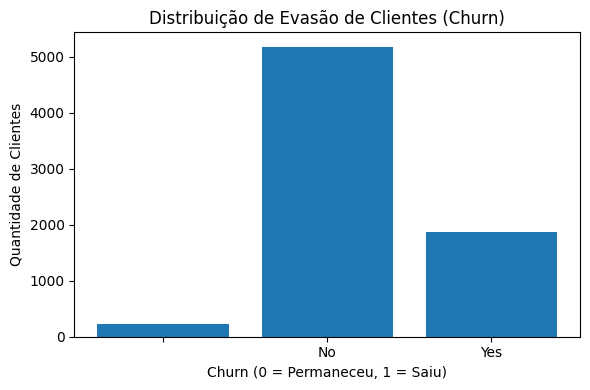

In [41]:
#Gráfico de Barras – Distribuição de Churn
import matplotlib.pyplot as plt

counts = df["Churn"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Churn (0 = Permaneceu, 1 = Saiu)")
plt.ylabel("Quantidade de Clientes")
plt.title("Distribuição de Evasão de Clientes (Churn)")
plt.tight_layout()
plt.show()


In [42]:
df["Churn"] = df["Churn"].replace("", pd.NA).map({"No":0, "Yes":1}).astype('Int64')


Counts:
 Churn
0       5174
1       1869
<NA>     224
Name: count, dtype: Int64
Índices: [0, 1, <NA>]


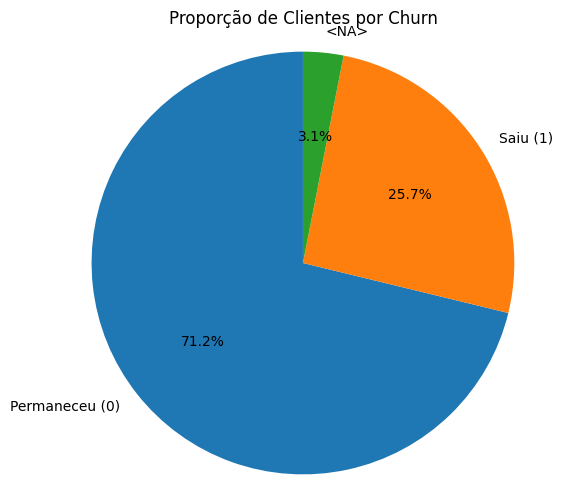

In [43]:
#Gráfico de Pizza – Proporção de Churn
import matplotlib.pyplot as plt


counts = df["Churn"].value_counts(dropna=False).sort_index()


print("Counts:\n", counts)
print("Índices:", counts.index.tolist())


mapping = {
    0: "Permaneceu (0)",
    1: "Saiu (1)",
    "No": "Permaneceu (No)",
    "Yes": "Saiu (Yes)",
    "": "Vazio",
    None: "NaN"
}
labels = [mapping.get(idx, str(idx)) for idx in counts.index]

# 4) plot seguro do gráfico pizza
plt.figure(figsize=(6,6))
plt.pie(counts.values, labels=labels, autopct="%1.1f%%", startangle=90)
plt.title("Proporção de Clientes por Churn")
plt.axis('equal')
plt.show()


In [44]:
#Função para gerar gráficos automaticamente
import matplotlib.pyplot as plt
import seaborn as sns

def churn_por_categoria(df, coluna):
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=coluna, hue="Churn")
    plt.title(f"Churn por {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Contagem")
    plt.xticks(rotation=45)
    plt.legend(title="Churn", labels=["0 = Permaneceu", "1 = Saiu"])
    plt.tight_layout()
    plt.show()

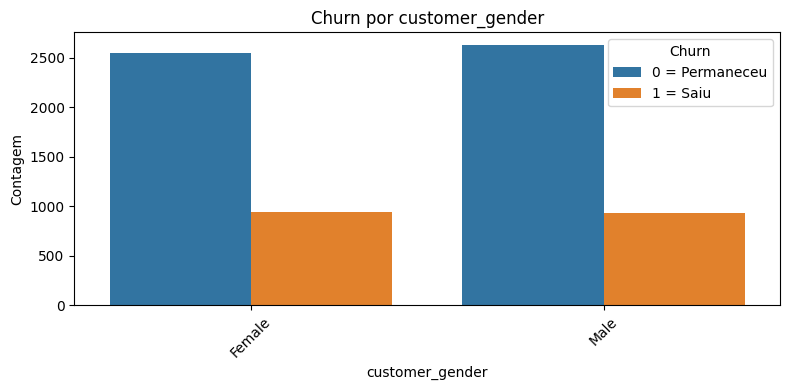

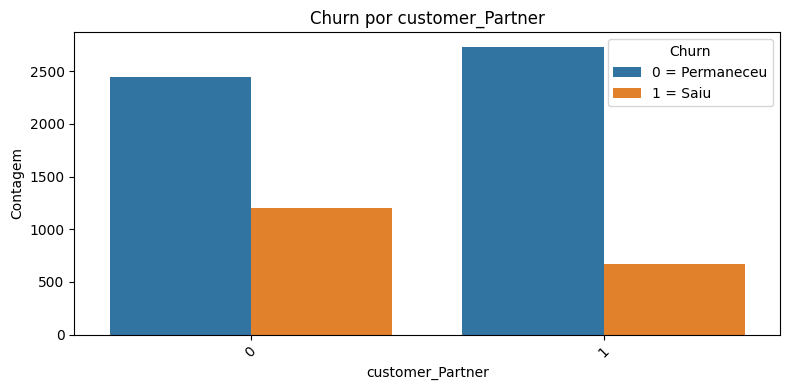

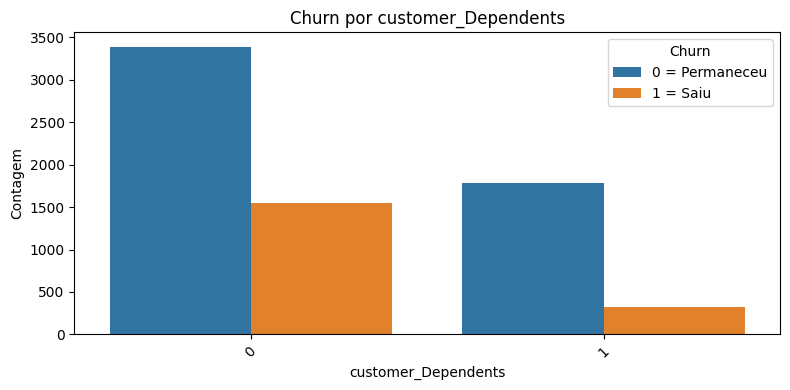

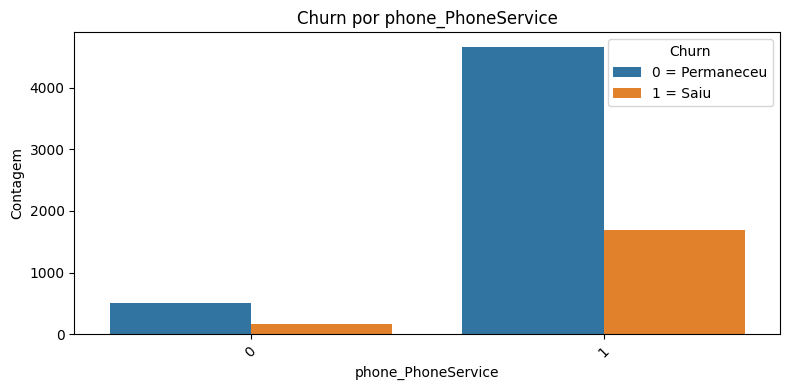

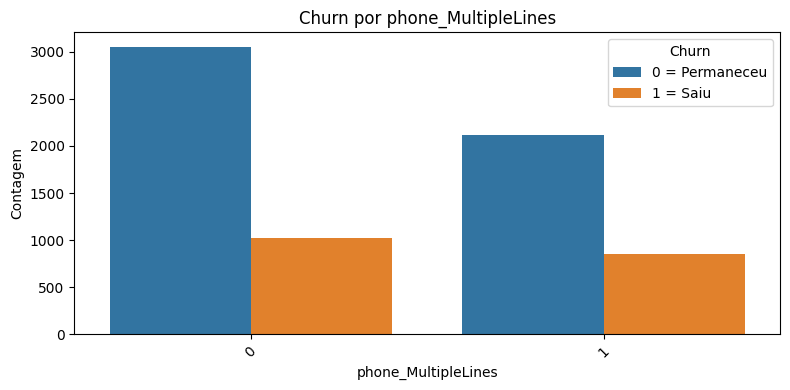

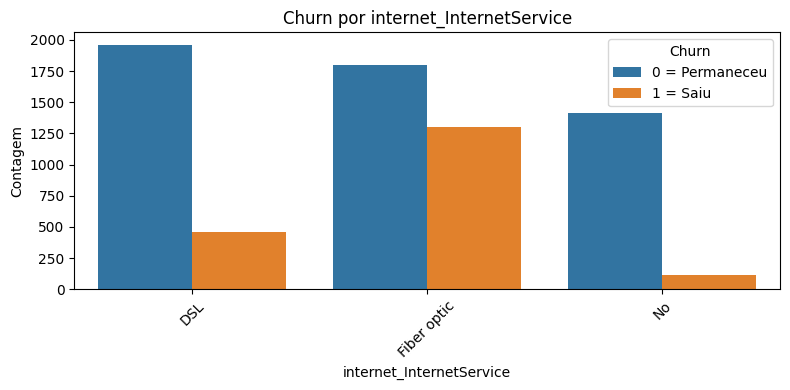

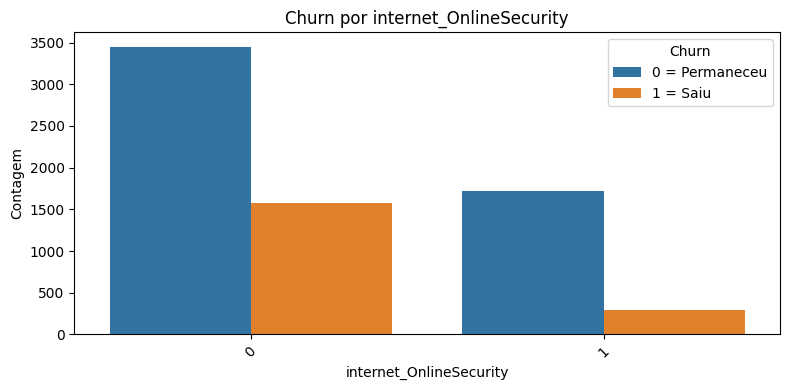

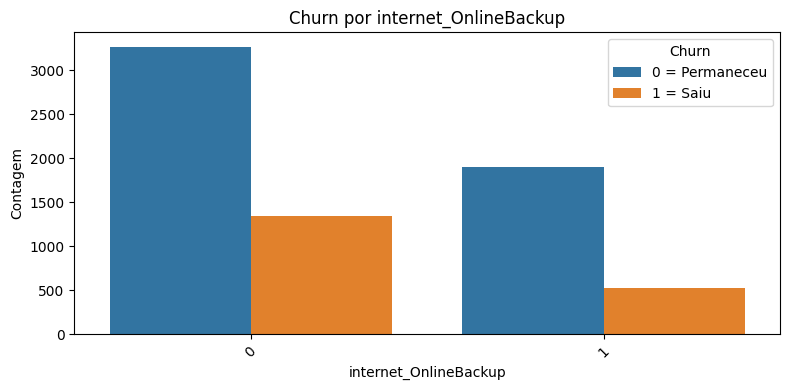

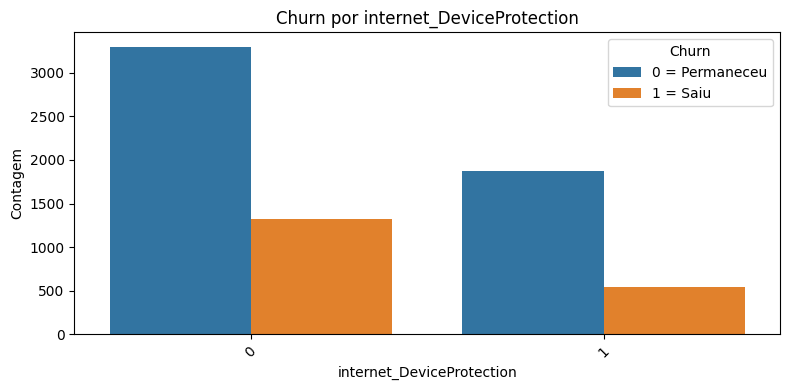

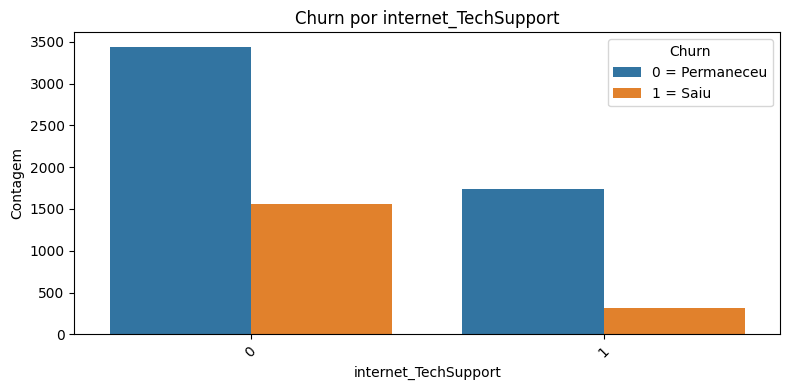

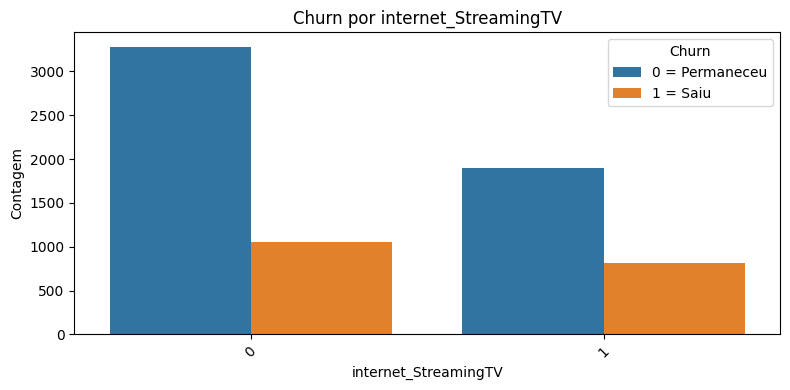

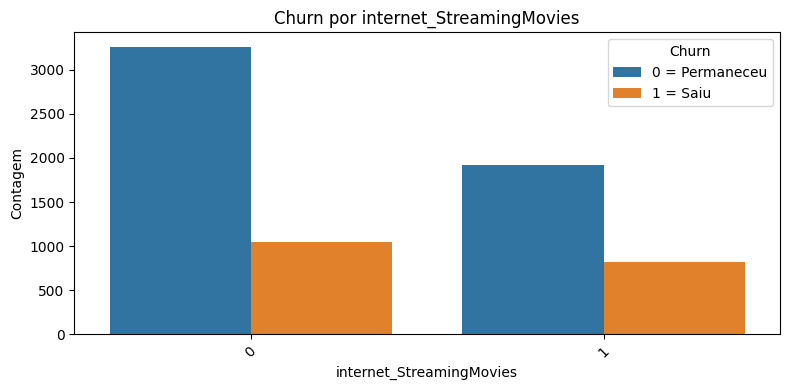

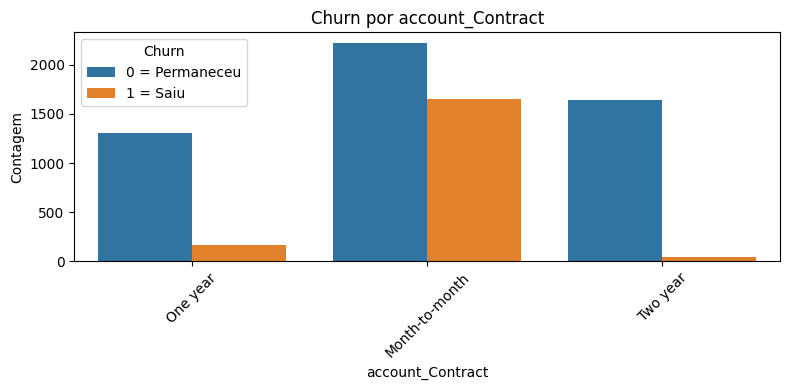

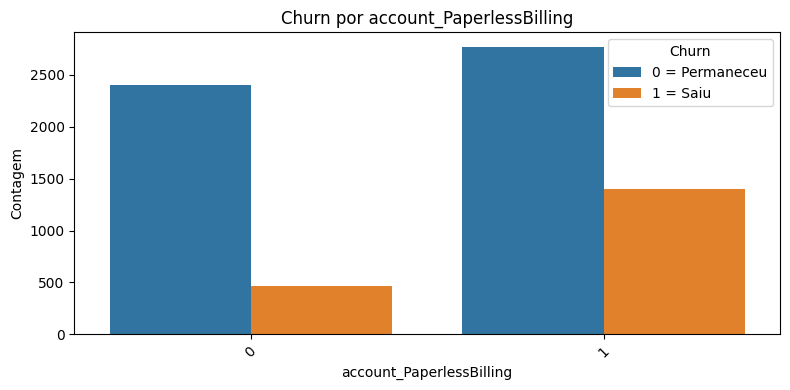

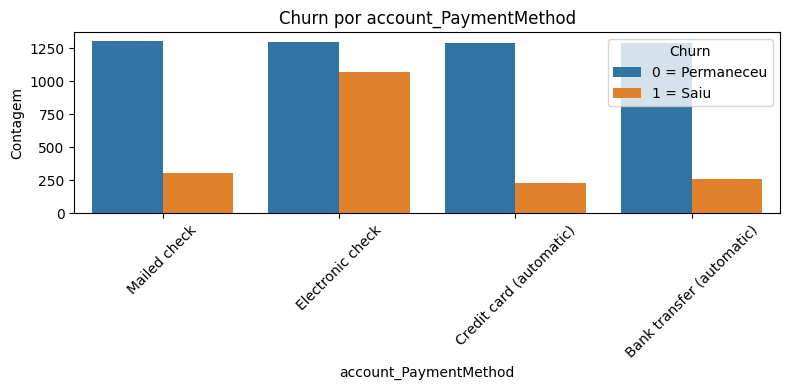

In [45]:
#Gerar gráficos para todas as categorias principais
categorias = [
    "customer_gender",
    "customer_Partner",
    "customer_Dependents",
    "phone_PhoneService",
    "phone_MultipleLines",
    "internet_InternetService",
    "internet_OnlineSecurity",
    "internet_OnlineBackup",
    "internet_DeviceProtection",
    "internet_TechSupport",
    "internet_StreamingTV",
    "internet_StreamingMovies",
    "account_Contract",
    "account_PaperlessBilling",
    "account_PaymentMethod"
]

for coluna in categorias:
    churn_por_categoria(df, coluna)

In [46]:
# Converter Total Charges para numérico
df["account_Charges.Total"] = pd.to_numeric(df["account_Charges.Total"], errors="coerce")

# Verificar se deu certo
print(df["account_Charges.Total"].dtypes)
print(df["account_Charges.Total"].describe())


float64
count    7256.000000
mean     2280.634213
std      2268.632997
min        18.800000
25%       400.225000
50%      1391.000000
75%      3785.300000
max      8684.800000
Name: account_Charges.Total, dtype: float64


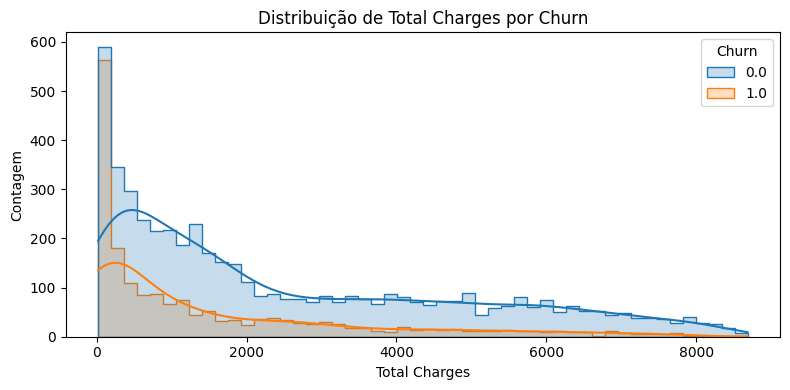

In [47]:
#Boxplot – Distribuição por Churn
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.histplot(
    data=df,
    x="account_Charges.Total",
    hue="Churn",
    kde=True,
    element="step",
    bins=50
)
plt.title("Distribuição de Total Charges por Churn")
plt.xlabel("Total Charges")
plt.ylabel("Contagem")
plt.tight_layout()
plt.show()


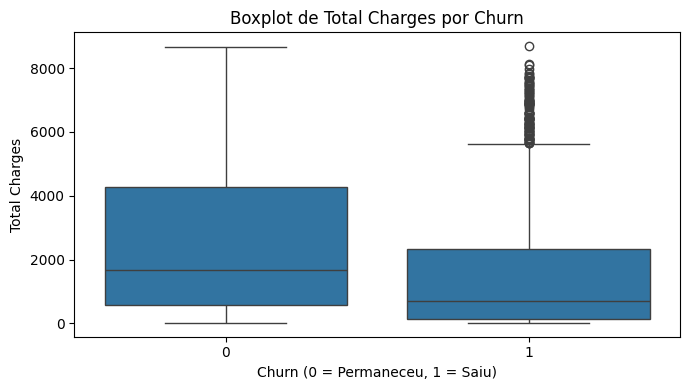

In [48]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="Churn", y="account_Charges.Total")
plt.title("Boxplot de Total Charges por Churn")
plt.xlabel("Churn (0 = Permaneceu, 1 = Saiu)")
plt.ylabel("Total Charges")
plt.tight_layout()
plt.show()

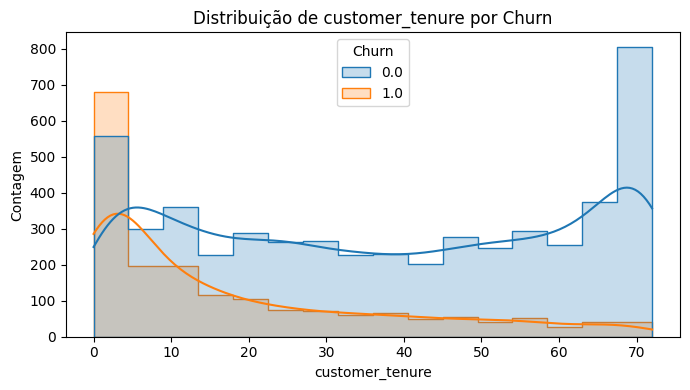

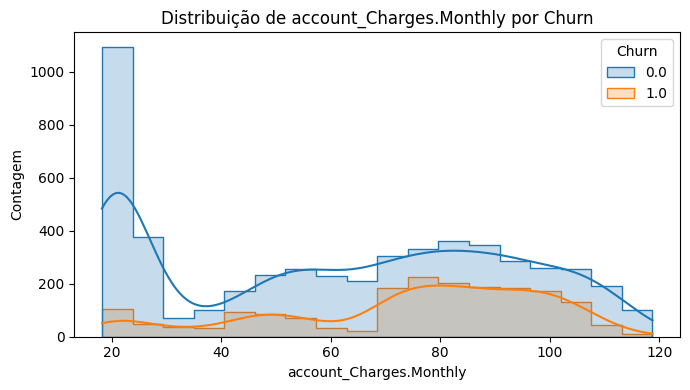

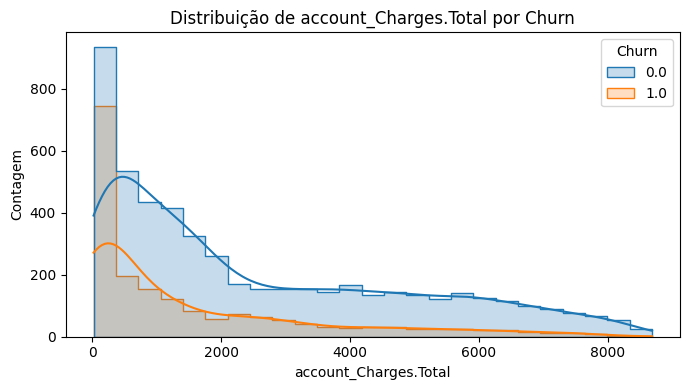

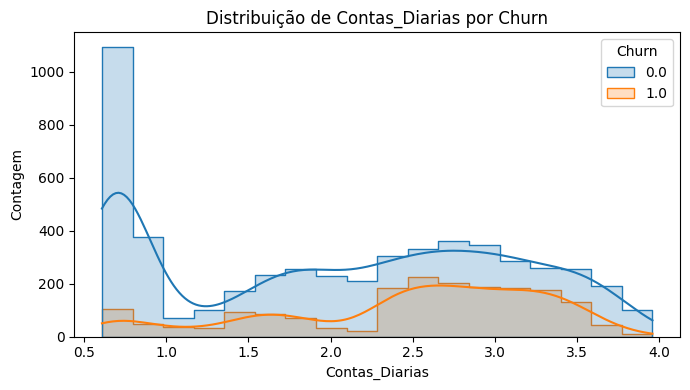

In [49]:
#Histogramas (ou KDE) – Comparando Curvas
def hist_churn(df, coluna):
    plt.figure(figsize=(7,4))
    sns.histplot(data=df, x=coluna, hue="Churn", kde=True, element="step")
    plt.title(f"Distribuição de {coluna} por Churn")
    plt.xlabel(coluna)
    plt.ylabel("Contagem")
    plt.tight_layout()
    plt.show()

hist_churn(df, "customer_tenure")
hist_churn(df, "account_Charges.Monthly")
hist_churn(df, "account_Charges.Total")
hist_churn(df, "Contas_Diarias")


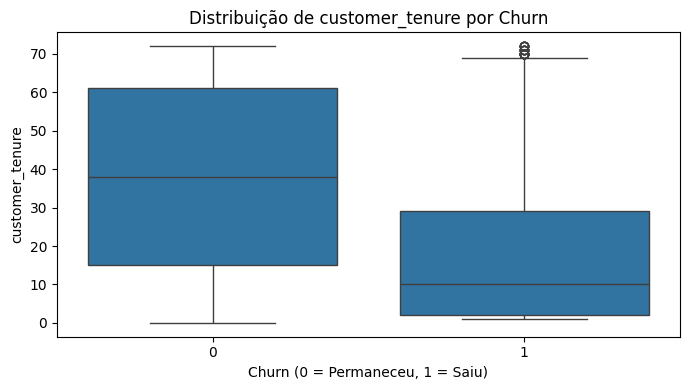

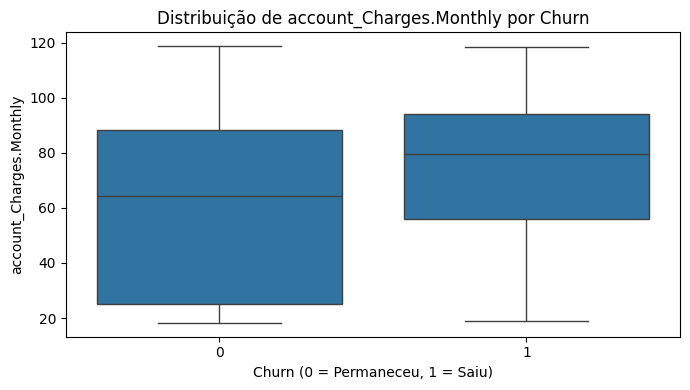

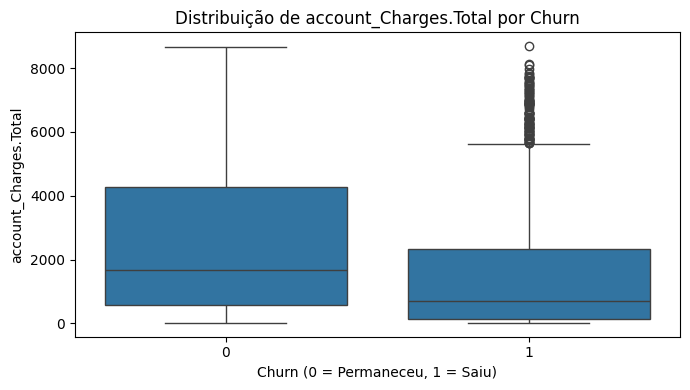

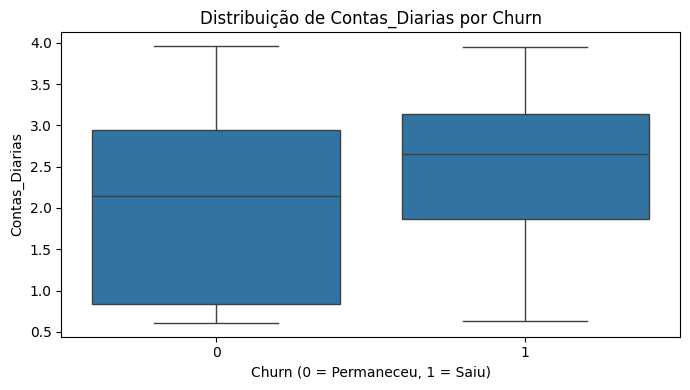

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

def boxplot_churn(df, coluna):
    plt.figure(figsize=(7,4))
    sns.boxplot(data=df, x="Churn", y=coluna)
    plt.title(f"Distribuição de {coluna} por Churn")
    plt.xlabel("Churn (0 = Permaneceu, 1 = Saiu)")
    plt.ylabel(coluna)
    plt.tight_layout()
    plt.show()

boxplot_churn(df, "customer_tenure")
boxplot_churn(df, "account_Charges.Monthly")
boxplot_churn(df, "account_Charges.Total")
boxplot_churn(df, "Contas_Diarias")


In [51]:
#Comparação direta das médias
df.groupby("Churn")[["customer_tenure",
                     "account_Charges.Monthly",
                     "account_Charges.Total",
                     "Contas_Diarias"]].mean()


,customer_tenure,account_Charges.Monthly,account_Charges.Total,Contas_Diarias
Churn,,,,
0,37.569965,61.265124,2555.344141,2.042171
1,17.979133,74.441332,1531.796094,2.481378


In [52]:
df["account_Charges.Total"].unique()[:20]

array([ 593.3 ,  542.4 ,  280.85, 1237.85,  267.4 ,  571.45, 7904.25,
       5377.8 ,  340.35, 5957.9 , 2460.55, 8456.75,  351.5 , 7261.25,
       2560.1 , 6849.4 , 1993.2 ,   72.1 , 2791.5 ,   25.1 ])

#📄Relatorio Final

# 📊 RELATÓRIO FINAL – Análise de Churn – TelecomX
## 1. Introdução

Este relatório apresenta uma análise sobre a evasão de clientes (churn) na empresa TelecomX, que vem enfrentando um aumento no número de cancelamentos.

O objetivo do estudo é identificar padrões de comportamento dos clientes e entender quais fatores podem influenciar o cancelamento dos serviços.

Principais objetivos:

✔ Identificar perfis de clientes com maior chance de churn<br>
✔ Avaliar o impacto de serviços e tipos de contrato<br>
✔ Gerar insights que ajudem na redução da evasão

A análise foi dividida em quatro etapas: extração dos dados, tratamento, análise exploratória e geração de insights.

## 2. Limpeza e Tratamento dos Dados

Após importar o dataset TelecomX_Data.json, foram realizadas etapas de preparação para melhorar a qualidade dos dados.

2.1 Padronização de Variáveis

A coluna Churn foi convertida para valores binários:

No → 0

Yes → 1

Algumas categorias inconsistentes como "No internet service" e "No phone service" foram padronizadas para “No”.

2.2 Conversão de Tipos

Colunas numéricas como:

account_Charges.Monthly

account_Charges.Total

foram convertidas para formato float, corrigindo valores inválidos.

2.3 Nova Variável

Foi criada a coluna Contas_Diarias, calculada a partir da cobrança mensal:

Contas_Diarias = Cobrança Mensal / 30

2.4 Valores Ausentes

Valores inválidos foram tratados utilizando errors="coerce", além da verificação de categorias com value_counts().

##3. Análise Exploratória (EDA)

A análise exploratória buscou identificar relações entre as variáveis e o churn.

3.1 Distribuição de Churn

Gráficos de barras e pizza mostraram a proporção de clientes que cancelaram e os que permaneceram.

✔ A base apresenta uma quantidade relevante de churn<br>
✔ Existe um leve desbalanceamento entre as classes<br>

3.2 Variáveis Categóricas

Alguns padrões importantes foram identificados.

🔸 Tipo de Contrato

Clientes com contratos Month-to-month apresentam maior taxa de cancelamento.

✔ Contratos One-year e Two-year possuem churn bem menor.

🔸 Serviços de Internet

Usuários de Fiber optic demonstram maior evasão, enquanto clientes DSL tendem a permanecer mais.

🔸 Serviços adicionais

Clientes sem:

OnlineSecurity

TechSupport

DeviceProtection

apresentam maior probabilidade de cancelar.

🔸 Método de Pagamento

O método Electronic Check concentra muitos clientes que cancelaram.

3.3 Variáveis Numéricas

Algumas variáveis também mostraram relação com o churn.

🔸 Tempo de Permanência (tenure)

Clientes que cancelaram geralmente possuem menos tempo na empresa.

🔸 Cobrança Mensal

Clientes com churn pagam mensalidades mais altas em média.

🔸 Total Gasto

Os valores totais gastos pelos churners são menores, indicando cancelamentos precoces.

🔸 Contas Diárias

Clientes que cancelaram apresentam valores diários ligeiramente maiores.

##4. Conclusões e Insights

A análise mostrou alguns fatores relacionados ao churn na TelecomX.

✔ Clientes novos cancelam mais<br>
✔ Contratos Month-to-month possuem maior evasão<br>
✔ Mensalidades mais altas aumentam o risco de churn<br>
✔ Ausência de serviços adicionais está associada a cancelamentos<br>
✔ Electronic Check aparece com frequência entre churners<br>
✔ Clientes de fibra óptica apresentam maior taxa de evasão<br>

Esses padrões são comuns em empresas do setor de telecomunicações.

##5. Recomendações

Com base nos resultados obtidos, algumas ações podem ajudar a reduzir o churn:

✔ Criar estratégias de retenção para novos clientes<br>
✔ Oferecer benefícios para usuários de fibra óptica<br>
✔ Incentivar o uso de serviços de segurança e suporte<br>
✔ Tornar planos Month-to-month mais atrativos<br>
✔ Estimular métodos de pagamento automáticos<br>

Além disso, os dados preparados permitem futuramente desenvolver um modelo preditivo de churn, ajudando a empresa a identificar clientes com maior risco de cancelamento.